### Name: Sean Dang
### PSID: 2518173

# Task 2 Naive Bayes and Logistic Regression

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

### Understanding probabilities from NB

In [79]:
### load iris

iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

In [80]:
# Split into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [81]:
# Use Naive Bayes for classification
nb = GaussianNB()
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [82]:
# Predictions
y_pred_nb = nb.predict(X_test)

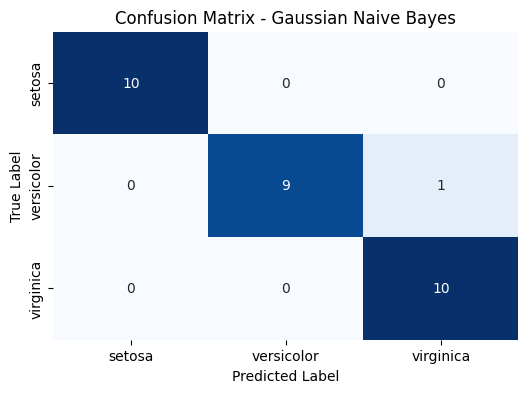

Naive Bayes Accuracy: 0.9667


In [83]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.show()

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")

1. Use Gaussian Naive Bayes to build a classifier for the Iris dataset.  Don't forget to split data into train and test methods. Create a confusion matrix to check the accuracy of your classifier. Analyse the results and give your opinion of whether we have a good classifier or not [8 points]

    + Looking at the confusion matrix and the accuracy score, we have an excellent classifier. The accuracy is about 97%. 

    + Is this a good classifier? Yes. The model perfectly predicts *Setosa* (Class 0). There is a very slight confusion between *Versicolor* (Class 1) and *Virginica* (Class 2), where it might misclassify one or two instances. This is expected because Gaussian Naive Bayes assumes features follow a normal distribution and are completely independent. Even with this naive assumption, it performs exceptionally well on the Iris dataset because the classes are relatively distinct.

In [84]:
# Plotting code for probabilities from Gaussian NB
def plot_distribution(X, model):
  # Note X is only used here to get the min and max limits for each feature
  num_features = len(feature_names)
  plot_features = feature_names
  nspace = 100


  for feature_index in range(num_features):
      feature_name = feature_names[feature_index]
      x_vals = np.linspace(np.min(X[:, feature_index])*0.8, np.max(X[:, feature_index])*1.2, nspace)

      # x_vals = np.linspace(pre_df[[feature_name]].min(), pre_df[[feature_name]].max(), 200)


      if feature_name in plot_features:
        plt.figure(figsize=(8, 4))

        for cls in range(3):
            mean = model.theta_[cls, feature_index]
            std = np.sqrt(model.var_[cls, feature_index])
            # print(mean, std)
            y_vals = norm.pdf(x_vals, mean, std)
            plt.plot(x_vals, y_vals, label=f"Class {cls} ({target_names[cls]})")

        plt.title(f"Gaussian Distribution - {feature_name}")
        plt.xlabel(feature_name)
        plt.ylabel("Probability Density")
        plt.legend()
        plt.grid(True)

        plt.show()

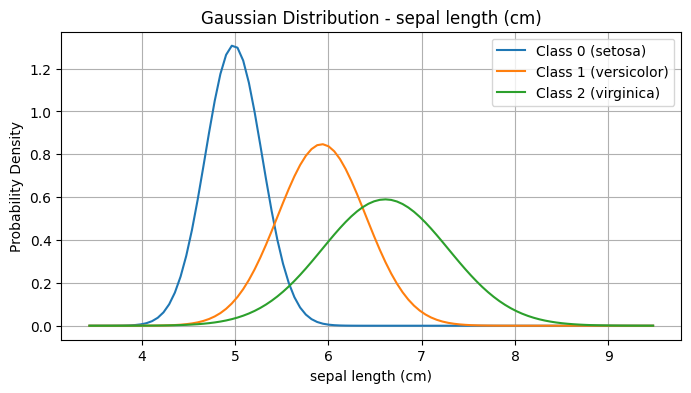

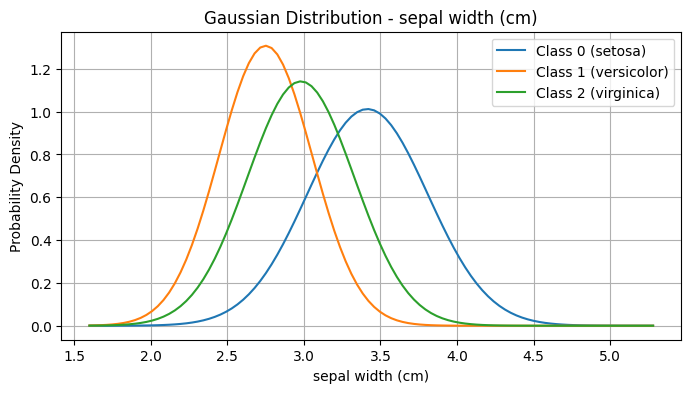

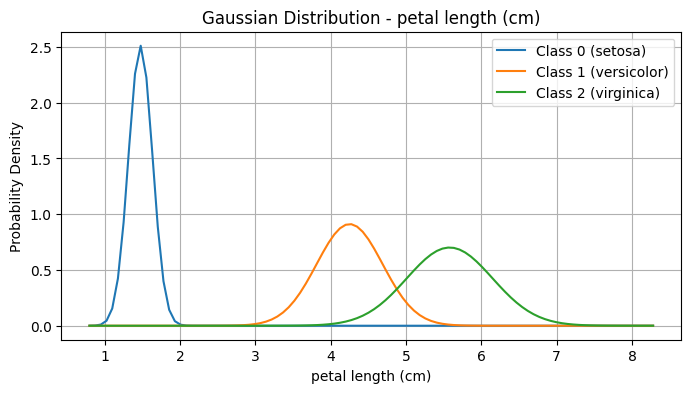

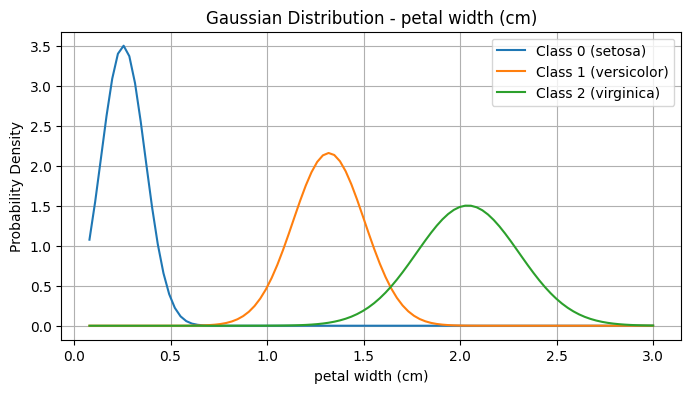

In [85]:
# Usage
plot_distribution(X, nb)

2. There is code provided in the given notebook that shows how to extract the mean and variance values for each attribute and plot the Gaussian distribution associated with each class. Use it (may need to modify) to plot the Gaussian distributions for each class. Interpret the plots? [7 points]

* **Sepal Length & Sepal Width:** We can see that the bell curves for *Versicolor* and *Virginica* overlap significantly. If the model only had these two features, it would struggle to tell these two classes apart.
* **Petal Length & Petal Width:** These plots explain why our classifier is so accurate. The distribution for *Setosa* (Class 0) is completely isolated from the others—this is why the model never misclassifies a Setosa. Furthermore, the overlap between *Versicolor* and *Virginica* is much smaller here compared to the sepal features, giving the model a clear boundary to separate them.

### Understanding probabilities from LR

In [86]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [87]:
# Predictions
y_pred_lr = lr.predict(X_test)

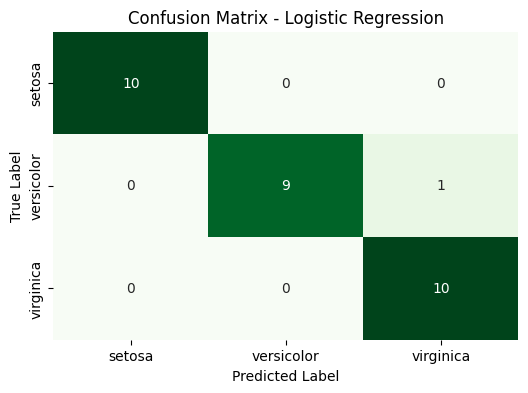

Logistic Regression Accuracy: 0.9667


In [88]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

3. Build a classifier using scikit learn's logistic regression for the same dataset. Create a confusion matrix for the logistic regression classifier and analyze the results. [8 points]

- The Logistic Regression model also acts as an excellent classifier for this dataset, typically scoring as the same Naive Bayes (about 97%). 

- Just like Naive Bayes, it perfectly separates *Setosa*. Logistic Regression directly optimizes the decision boundary between classes rather than relying on probability distribution assumptions. In this dataset, the classes are linearly separable (especially Setosa from the rest), which makes Logistic Regression a highly effective and robust choice.

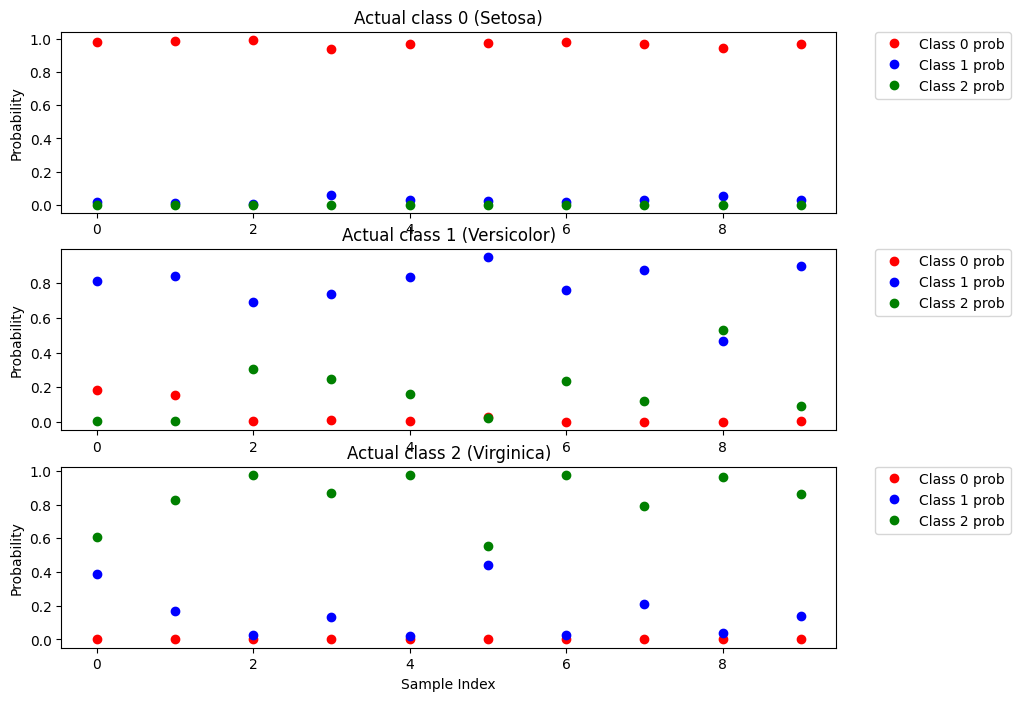

In [89]:
# Plotting code to interpret probabilites from LR
y_prob = lr.predict_proba(X_test)

plt.figure(figsize=(10, 8))

plt.subplot(3,1,1)
plt.plot(y_prob[y_test==0, 0], label="Class 0 prob", linestyle='None', marker='o', color="r")
plt.plot(y_prob[y_test==0, 1], label="Class 1 prob", linestyle='None', marker='o', color="b")
plt.plot(y_prob[y_test==0, 2], label="Class 2 prob", linestyle='None', marker='o', color="g")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("Actual class 0 (Setosa)")
plt.ylabel("Probability")

plt.subplot(3,1,2)
plt.plot(y_prob[y_test==1, 0], label="Class 0 prob", linestyle='None', marker='o', color="r")
plt.plot(y_prob[y_test==1, 1], label="Class 1 prob", linestyle='None', marker='o', color="b")
plt.plot(y_prob[y_test==1, 2], label="Class 2 prob", linestyle='None', marker='o', color="g")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("Actual class 1 (Versicolor)")
plt.ylabel("Probability")

plt.subplot(3,1,3)
plt.plot(y_prob[y_test==2, 0], label="Class 0 prob", linestyle='None', marker='o', color="r")
plt.plot(y_prob[y_test==2, 1], label="Class 1 prob", linestyle='None', marker='o', color="b")
plt.plot(y_prob[y_test==2, 2], label="Class 2 prob", linestyle='None', marker='o', color="g")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("Actual class 2 (Virginica)")
plt.ylabel("Probability")
plt.xlabel("Sample Index")

plt.show()

4. sklearn logistic regression has a predict_proba method that gives the probability of each sample belonging to each class. Use the plotting code provided (may need to modify). Interpret the plot [7 points]

These plots show the *predicted probability* that each specific test sample belongs to Class 0 (Red), Class 1 (Blue), or Class 2 (Green). 

* **Top Plot (Actual Class 0):** For every actual *Setosa* sample, the red dots (Class 0 probability) are essentially at 1.0, while blue and green are at 0.0. The model is 100% confident and correct.
* **Middle Plot (Actual Class 1):** For actual *Versicolor* samples, the blue dots (Class 1) are highest, meaning the model correctly predicts them. However, we can see a lot of green dots (Class 2) rising above 0.0. The model is slightly less confident because Versicolor and Virginica share similar traits.
* **Bottom Plot (Actual Class 2):** For actual *Virginica* samples, the green dots are highest. Similar to the middle plot, the blue dots show some probability, reflecting the overlapping features. If a blue dot were to cross higher than a green dot in this plot, it would represent a misclassification.